# Sample Variance Reduction Analysis

This notebook implements the bootstrapping approach to demonstrate that the standard deviation of distance scores decreases as we increase:
- m: number of guide images
- l: number of embedders

## Methodology

1. **Data Collection**: Generate a pool of guide images (M_pool=20) for each query
2. **Bootstrapping**: Sample m images and l embedders, compute distance scores, repeat 100 times
3. **Analysis**: Calculate standard deviation for each (m, l) configuration
4. **Visualization**: Plot σ vs m to show the 1/√m decay pattern


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from typing import List, Dict, Tuple
from collections import defaultdict
import base64
from io import BytesIO
from PIL import Image
import time
import hashlib
from pathlib import Path
import pandas as pd
import random

# Configuration
BACKEND_URL = "http://localhost:8000"  # Adjust if needed
POOL_SIZE = 20  # M_pool: number of guide images to generate
BOOTSTRAP_ITERATIONS = 100  # Number of bootstrap samples
DEBUG_IMAGES_DIR = "debug_images"  # Directory to save guide images for debugging

# CSV files and image paths
METADATA_CSV = "metadata.csv"
QUERIES_CSV = "queries.csv"
IMAGES_BASE_PATH = "/home/mahdi/Datasets/Caltech256/all_images"  # Set this to the base path where images are stored (e.g., "/path/to/images/")
NUM_QUERIES = 50  # Number of queries to randomly select

# Values to test
M_VALUES = [1, 3, 5, 10, 15, 20]  # Number of guide images
L_VALUES = [1, 2, 4, 6]  # Number of embedders (adjust based on available embedders)

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)


## Step 0: Load Queries and Metadata

First, we load the queries and metadata CSV files, then randomly select 50 queries.


In [2]:
# Load CSV files
print("Loading CSV files...")
metadata_df = pd.read_csv(METADATA_CSV)
queries_df = pd.read_csv(QUERIES_CSV)

print(f"Loaded {len(metadata_df)} image entries from {METADATA_CSV}")
print(f"Loaded {len(queries_df)} queries from {QUERIES_CSV}")

# Randomly select NUM_QUERIES queries
if len(queries_df) < NUM_QUERIES:
    print(f"Warning: Only {len(queries_df)} queries available, using all of them")
    selected_queries = queries_df['query'].tolist()
else:
    selected_queries = random.sample(queries_df['query'].tolist(), NUM_QUERIES)

print(f"\nSelected {len(selected_queries)} queries for analysis")
print(f"Sample queries: {selected_queries[:5]}")

# Verify images base path is set
if IMAGES_BASE_PATH is None:
    print("\n⚠️  WARNING: IMAGES_BASE_PATH is not set!")
    print("Please set IMAGES_BASE_PATH to the directory containing the images.")
    print("Example: IMAGES_BASE_PATH = '/path/to/caltech256/images/'")
    raise ValueError("IMAGES_BASE_PATH must be set to the base directory containing images")
else:
    images_path = Path(IMAGES_BASE_PATH)
    if not images_path.exists():
        raise ValueError(f"Images base path does not exist: {IMAGES_BASE_PATH}")
    print(f"\n✓ Images base path: {IMAGES_BASE_PATH}")


Loading CSV files...
Loaded 30607 image entries from metadata.csv
Loaded 257 queries from queries.csv

Selected 50 queries for analysis
Sample queries: ['doorknob', 'birdbath', 'snake', 'fire-hydrant', 'electric-guitar-101']

✓ Images base path: /home/mahdi/Datasets/Caltech256/all_images


## Step 1: Load Embedders and Compute Ground Truth Embeddings


In [3]:
# Get embedder names from backend API
def get_embedder_names():
    """Get list of available embedder names from backend."""
    try:
        # We'll get this from the first API call, or create a simple endpoint
        # For now, we'll get it from the compute-embeddings response
        response = requests.post(
            f"{BACKEND_URL}/variance-analysis/compute-embeddings",
            json={"image_paths": []}  # Empty list just to get embedder names
        )
        if response.status_code == 200:
            data = response.json()
            return data.get("embedder_names", [])
    except Exception as e:
        print(f"Warning: Could not get embedder names: {e}")
    return []


def compute_embeddings_for_images(image_paths: List[str]) -> Dict[str, Dict[str, np.ndarray]]:
    """
    Compute embeddings for multiple images using backend API.
    
    Args:
        image_paths: List of image file paths
    
    Returns:
        Dict mapping image_path -> Dict mapping embedder_name -> embedding array
    """
    if not image_paths:
        return {}
    
    response = requests.post(
        f"{BACKEND_URL}/variance-analysis/compute-embeddings",
        json={"image_paths": image_paths}
    )
    
    if response.status_code != 200:
        raise Exception(f"Failed to compute embeddings: {response.text}")
    
    data = response.json()
    results = {}
    
    for result in data["results"]:
        image_path = result["image_path"]
        embeddings_dict = {}
        for emb_data in result["embeddings"]:
            embeddings_dict[emb_data["embedder_name"]] = np.array(emb_data["embedding"])
        results[image_path] = embeddings_dict
    
    return results


# Get embedder names
print("Getting embedder information from backend...")
embedder_names = None
try:
    # Try to get embedder names by making a minimal request
    test_response = requests.post(
        f"{BACKEND_URL}/variance-analysis/compute-embeddings",
        json={"image_paths": []}
    )
    if test_response.status_code == 200:
        embedder_names = test_response.json().get("embedder_names", [])
        print(f"✓ Found {len(embedder_names)} embedders: {embedder_names}")
except Exception as e:
    print(f"⚠️  Could not get embedder names: {e}")
    print("Will discover embedders from first embedding computation")


def get_ground_truth_embeddings(query: str, metadata_df: pd.DataFrame, 
                                images_base_path: Path) -> Dict[str, np.ndarray]:
    """
    Get ground truth embeddings for a query by averaging embeddings of all images
    that match the query category.
    
    Args:
        query: The query string (object name)
        metadata_df: DataFrame with filename and categories columns
        images_base_path: Base path to images directory
    
    Returns:
        Dict mapping embedder_name -> ground truth embedding (average of matching images)
    """
    # Find all images that match this query
    matching_images = metadata_df[metadata_df['categories'] == query]
    
    if len(matching_images) == 0:
        print(f"  Warning: No images found for query '{query}'")
        return {}
    
    print(f"  Found {len(matching_images)} images for query '{query}'")
    
    # Collect all image paths
    image_paths = []
    for idx, row in matching_images.iterrows():
        filename = row['filename']
        image_path = images_base_path / filename
        if image_path.exists():
            image_paths.append(str(image_path))
        else:
            print(f"    Warning: Image not found: {image_path}")
    
    if not image_paths:
        print(f"  Warning: No valid image paths for query '{query}'")
        return {}
    
    # Compute embeddings in batches (to avoid overwhelming the API)
    batch_size = 50  # Process 50 images at a time
    all_embeddings_dict = {}
    discovered_embedder_names = None
    
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        print(f"    Processing batch {i//batch_size + 1}/{(len(image_paths)-1)//batch_size + 1} ({len(batch_paths)} images)...")
        
        batch_results = compute_embeddings_for_images(batch_paths)
        
        # Initialize embedder lists if first batch
        if not all_embeddings_dict:
            # Get embedder names from first result
            if batch_results:
                first_result = list(batch_results.values())[0]
                discovered_embedder_names = list(first_result.keys())
                all_embeddings_dict = {name: [] for name in discovered_embedder_names}
        
        # Collect embeddings
        for image_path, embeddings in batch_results.items():
            for embedder_name, embedding in embeddings.items():
                if embedder_name in all_embeddings_dict:
                    all_embeddings_dict[embedder_name].append(embedding)
    
    # Update global embedder_names if it wasn't set before
    if discovered_embedder_names and embedder_names is None:
        # We can't modify the outer scope variable directly, but we can note it
        print(f"    Discovered embedders: {discovered_embedder_names}")
    
    # Compute average embeddings (ground truth) for each embedder
    ground_truth_embeddings = {}
    for embedder_name, embeddings_list in all_embeddings_dict.items():
        if len(embeddings_list) > 0:
            ground_truth_embeddings[embedder_name] = np.mean(embeddings_list, axis=0)
            print(f"    {embedder_name}: averaged {len(embeddings_list)} embeddings")
        else:
            print(f"    Warning: No embeddings computed for {embedder_name}")
    
    return ground_truth_embeddings


# Compute ground truth embeddings for all selected queries
print("\nComputing ground truth embeddings...")
ground_truth_embeddings_by_query = {}

for query in selected_queries:
    print(f"\nProcessing query: {query}")
    gt_embeddings = get_ground_truth_embeddings(query, metadata_df, images_path)
    if gt_embeddings:
        ground_truth_embeddings_by_query[query] = gt_embeddings
    else:
        print(f"  Skipping query '{query}' - no ground truth embeddings computed")

print(f"\n✓ Computed ground truth embeddings for {len(ground_truth_embeddings_by_query)} queries")


Getting embedder information from backend...
✓ Found 6 embedders: ['eva', 'regnet', 'dino', 'clip', 'convnextv2', 'bevit']

Computing ground truth embeddings...

Processing query: doorknob
  Found 93 images for query 'doorknob'
    Processing batch 1/2 (50 images)...
    Processing batch 2/2 (43 images)...
    eva: averaged 93 embeddings
    regnet: averaged 93 embeddings
    dino: averaged 93 embeddings
    clip: averaged 93 embeddings
    convnextv2: averaged 93 embeddings
    bevit: averaged 93 embeddings

Processing query: birdbath
  Found 98 images for query 'birdbath'
    Processing batch 1/2 (50 images)...
    Processing batch 2/2 (48 images)...
    eva: averaged 98 embeddings
    regnet: averaged 98 embeddings
    dino: averaged 98 embeddings
    clip: averaged 98 embeddings
    convnextv2: averaged 98 embeddings
    bevit: averaged 98 embeddings

Processing query: snake
  Found 112 images for query 'snake'
    Processing batch 1/3 (50 images)...
    Processing batch 2/3 (50 im

In [4]:
## Step 2: Generate Guide Image Pools

def generate_pool(query: str, pool_size: int = POOL_SIZE) -> Dict:
    """
    Generate a pool of guide images and compute embeddings.
    Returns the API response with guide images and embeddings.
    """
    # You'll need to configure this based on your generator setup
    # This is a template - adjust the engine config based on your setup
    generation_config = {
        "engines": [
            {
                "name": "SDTurbo",  # Adjust based on available generators
                "params": {}
            }
        ],
        "num_engines_to_use": 1,
        "num_images": pool_size,  # Generate pool_size images
        "image_size": "SMALL",
        "use_fallback": True
    }
    
    request_data = {
        "query": query,
        "pool_size": pool_size,
        "generation_config": generation_config
    }
    
    response = requests.post(
        f"{BACKEND_URL}/variance-analysis/generate-pool",
        json=request_data
    )
    
    if response.status_code != 200:
        raise Exception(f"Failed to generate pool: {response.text}")
    
    return response.json()


def save_guide_images_to_disk(pool_data: Dict, query: str, base_dir: str = DEBUG_IMAGES_DIR):
    """
    Save guide images from pool_data to disk, organized by query.
    
    Args:
        pool_data: Response from generate_pool API
        query: The query string
        base_dir: Base directory to save images (default: "debug_images")
    """
    # Create a safe directory name from the query
    query_hash = hashlib.md5(query.encode()).hexdigest()[:8]
    # Sanitize query for directory name
    safe_query_name = "".join(c if c.isalnum() or c in (' ', '-', '_') else '_' for c in query)[:50]
    safe_query_name = safe_query_name.replace(' ', '_').strip('_')
    
    # Create directory for this query
    query_dir = Path(base_dir) / f"{safe_query_name}_{query_hash}"
    query_dir.mkdir(parents=True, exist_ok=True)
    
    # Save query text to a file for reference
    query_file = query_dir / "query.txt"
    query_file.write_text(query)
    
    # Save each guide image
    saved_count = 0
    for guide_img in pool_data["guide_images"]:
        idx = guide_img["image_index"]
        base64_image = guide_img["base64_image"]
        
        # Decode base64 image
        # Base64 images from API are in format: "data:image/png;base64,{data}"
        if base64_image.startswith("data:image"):
            # Extract the base64 part after the comma
            base64_data = base64_image.split(",")[1]
        else:
            base64_data = base64_image
        
        try:
            img_data = base64.b64decode(base64_data)
            img = Image.open(BytesIO(img_data))
            
            # Save image
            image_filename = query_dir / f"guide_image_{idx:03d}.png"
            img.save(image_filename, "PNG")
            saved_count += 1
        except Exception as e:
            print(f"  Warning: Failed to save image {idx}: {e}")
    
    print(f"  Saved {saved_count} images to {query_dir}")
    return query_dir


# Generate pools for all selected queries (only those with ground truth)
print("\nGenerating guide image pools...")
pools = {}
queries_to_process = list(ground_truth_embeddings_by_query.keys())

for query in queries_to_process:
    print(f"  Generating pool for: {query}")
    try:
        pool_data = generate_pool(query, POOL_SIZE)
        pools[query] = pool_data
        
        # Save images to disk for debugging
        save_guide_images_to_disk(pool_data, query)
        
        time.sleep(1)  # Rate limiting
    except Exception as e:
        print(f"  Error generating pool for '{query}': {e}")
        continue

print(f"\nGenerated {len(pools)} pools successfully")
print(f"Pool sizes: {[len(p['guide_images']) for p in pools.values()]}")
print(f"\nGuide images saved to '{DEBUG_IMAGES_DIR}/' directory for inspection")



Generating guide image pools...
  Generating pool for: doorknob
  Saved 20 images to debug_images/doorknob_9464cffd
  Generating pool for: birdbath
  Saved 20 images to debug_images/birdbath_1879444a
  Generating pool for: snake
  Saved 20 images to debug_images/snake_de1b2a7b
  Generating pool for: fire-hydrant
  Saved 20 images to debug_images/fire-hydrant_8242cb82
  Generating pool for: electric-guitar-101
  Saved 20 images to debug_images/electric-guitar-101_4e7ea7f1
  Generating pool for: clutter
  Saved 20 images to debug_images/clutter_b7023c00
  Generating pool for: chandelier-101
  Saved 20 images to debug_images/chandelier-101_44a2794a
  Generating pool for: snail
  Saved 20 images to debug_images/snail_d5ac70e3
  Generating pool for: calculator
  Saved 20 images to debug_images/calculator_48807664
  Generating pool for: rotary-phone
  Saved 20 images to debug_images/rotary-phone_a3fa9aae
  Generating pool for: tennis-shoes
  Saved 20 images to debug_images/tennis-shoes_558a

## Step 3: Distance Calculation Utilities


In [8]:
def cosine_distance(emb1: np.ndarray, emb2: np.ndarray) -> float:
    """Compute cosine distance between two embeddings."""
    # Cosine distance = 1 - cosine similarity
    dot_product = np.dot(emb1, emb2)
    norm1 = np.linalg.norm(emb1)                                                                                                                                                                                                                            
    norm2 = np.linalg.norm(emb2)
    if norm1 == 0 or norm2 == 0:
        return 1.0
    cosine_sim = dot_product / (norm1 * norm2)
    return 1.0 - cosine_sim


def compute_ground_truth_embedding(pool_data: Dict, embedder_name: str) -> np.ndarray:
    """
    Compute the ground truth embedding as the mean of all guide image embeddings
    for a given embedder.
    """
    embeddings = []
    for guide_img in pool_data["guide_images"]:
        for emb_data in guide_img["embeddings"]:
            if emb_data["embedder_name"] == embedder_name:
                embeddings.append(np.array(emb_data["embedding"]))
                break
    
    if not embeddings:
        raise ValueError(f"No embeddings found for embedder {embedder_name}")
    
    return np.mean(embeddings, axis=0)


def compute_distance_score(
    selected_images: List[Dict],
    selected_embedders: List[str],
    ground_truth_embeddings: Dict[str, np.ndarray]
) -> float:
    """
    Compute the average distance score δ_bar for selected images and embedders.
    
    Args:
        selected_images: List of guide image data (with embeddings)
        selected_embedders: List of embedder names to use
        ground_truth_embeddings: Dict mapping embedder_name -> ground truth embedding
    
    Returns:
        Average distance score
    """
    distances = []
    
    for guide_img in selected_images:
        for emb_data in guide_img["embeddings"]:
            if emb_data["embedder_name"] in selected_embedders:
                img_embedding = np.array(emb_data["embedding"])
                gt_embedding = ground_truth_embeddings[emb_data["embedder_name"]]
                
                dist = cosine_distance(img_embedding, gt_embedding)
                distances.append(dist)
    
    if not distances:
        return 0.0
    
    return np.mean(distances)


## Step 3: Bootstrapping Analysis


In [9]:
def bootstrap_analysis_vary_m(
    pool_data: Dict,
    query: str,
    m_values: List[int],
    l_fixed: int,
    bootstrap_iterations: int = BOOTSTRAP_ITERATIONS
) -> Dict[int, Tuple[float, float]]:
    """
    Vary m (number of guide images) while keeping l fixed.
    
    Returns:
        Dict mapping m -> (mean_distance, std_distance)
    """
    embedder_names = pool_data["embedder_names"]
    guide_images = pool_data["guide_images"]
    pool_size = len(guide_images)
    
    # Get pre-computed ground truth embeddings for this query
    if query not in ground_truth_embeddings_by_query:
        raise ValueError(f"No ground truth embeddings found for query '{query}'")
    
    ground_truth_embeddings = ground_truth_embeddings_by_query[query]
    
    # Select l_fixed embedders (use first l_fixed)
    selected_embedders = embedder_names[:l_fixed]
    
    results = {}
    
    for m in m_values:
        if m > pool_size:
            print(f"  Warning: m={m} > pool_size={pool_size}, skipping")
            continue
        
        distance_scores = []
        
        for _ in range(bootstrap_iterations):
            # Randomly sample m guide images
            selected_indices = np.random.choice(
                pool_size, size=m, replace=False
            )
            selected_images = [guide_images[i] for i in selected_indices]
            
            # Compute distance score
            distance = compute_distance_score(
                selected_images, selected_embedders, ground_truth_embeddings
            )
            distance_scores.append(distance)
        
        mean_dist = np.mean(distance_scores)
        std_dist = np.std(distance_scores)
        results[m] = (mean_dist, std_dist)
        
        print(f"  m={m}, l={l_fixed}: mean={mean_dist:.4f}, std={std_dist:.4f}")
    
    return results


def bootstrap_analysis_vary_l(
    pool_data: Dict,
    query: str,
    m_fixed: int,
    l_values: List[int],
    bootstrap_iterations: int = BOOTSTRAP_ITERATIONS
) -> Dict[int, Tuple[float, float]]:
    """
    Vary l (number of embedders) while keeping m fixed.
    
    Returns:
        Dict mapping l -> (mean_distance, std_distance)
    """
    embedder_names = pool_data["embedder_names"]
    guide_images = pool_data["guide_images"]
    pool_size = len(guide_images)
    
    if m_fixed > pool_size:
        raise ValueError(f"m_fixed={m_fixed} > pool_size={pool_size}")
    
    # Get pre-computed ground truth embeddings for this query
    if query not in ground_truth_embeddings_by_query:
        raise ValueError(f"No ground truth embeddings found for query '{query}'")
    
    ground_truth_embeddings = ground_truth_embeddings_by_query[query]
    
    results = {}
    
    for l in l_values:
        if l > len(embedder_names):
            print(f"  Warning: l={l} > num_embedders={len(embedder_names)}, skipping")
            continue
        
        distance_scores = []
        
        for _ in range(bootstrap_iterations):
            # Randomly sample m guide images
            selected_indices = np.random.choice(
                pool_size, size=m_fixed, replace=False
            )
            selected_images = [guide_images[i] for i in selected_indices]
            
            # Randomly select l embedders
            selected_embedders = list(np.random.choice(
                embedder_names, size=l, replace=False
            ))
            
            # Compute distance score
            distance = compute_distance_score(
                selected_images, selected_embedders, ground_truth_embeddings
            )
            distance_scores.append(distance)
        
        mean_dist = np.mean(distance_scores)
        std_dist = np.std(distance_scores)
        results[l] = (mean_dist, std_dist)
        
        print(f"  m={m_fixed}, l={l}: mean={mean_dist:.4f}, std={std_dist:.4f}")
    
    return results


## Step 4: Run Analysis


In [10]:
# Run analysis for each query (only those with both pools and ground truth)
all_results_vary_m = {}
all_results_vary_l = {}

queries_to_analyze = [q for q in pools.keys() if q in ground_truth_embeddings_by_query]

for query in queries_to_analyze:
    print(f"\n{'='*60}")
    print(f"Analyzing query: {query}")
    print(f"{'='*60}")
    
    pool_data = pools[query]
    
    # Vary m (fix l)
    print(f"\nVarying m (fixing l={L_VALUES[-1]})...")
    results_m = bootstrap_analysis_vary_m(
        pool_data, query, M_VALUES, l_fixed=L_VALUES[-1]
    )
    all_results_vary_m[query] = results_m
    
    # Vary l (fix m)
    print(f"\nVarying l (fixing m={M_VALUES[2]})...")
    results_l = bootstrap_analysis_vary_l(
        pool_data, query, m_fixed=M_VALUES[2], l_values=L_VALUES
    )
    all_results_vary_l[query] = results_l



Analyzing query: doorknob

Varying m (fixing l=6)...
  m=1, l=6: mean=0.3504, std=0.0349
  m=3, l=6: mean=0.3578, std=0.0218
  m=5, l=6: mean=0.3560, std=0.0164
  m=10, l=6: mean=0.3565, std=0.0104
  m=15, l=6: mean=0.3564, std=0.0049
  m=20, l=6: mean=0.3566, std=0.0000

Varying l (fixing m=5)...
  m=5, l=1: mean=0.3683, std=0.0939
  m=5, l=2: mean=0.3497, std=0.0625
  m=5, l=4: mean=0.3575, std=0.0335
  m=5, l=6: mean=0.3587, std=0.0164

Analyzing query: birdbath

Varying m (fixing l=6)...
  m=1, l=6: mean=0.3820, std=0.0466
  m=3, l=6: mean=0.3859, std=0.0320
  m=5, l=6: mean=0.3858, std=0.0239
  m=10, l=6: mean=0.3841, std=0.0151
  m=15, l=6: mean=0.3855, std=0.0069
  m=20, l=6: mean=0.3861, std=0.0000

Varying l (fixing m=5)...
  m=5, l=1: mean=0.3817, std=0.0579
  m=5, l=2: mean=0.3889, std=0.0405
  m=5, l=4: mean=0.3873, std=0.0272
  m=5, l=6: mean=0.3881, std=0.0247

Analyzing query: snake

Varying m (fixing l=6)...
  m=1, l=6: mean=0.5623, std=0.0402
  m=3, l=6: mean=0.5601, 

## Step 5: Aggregate Results Across Queries


In [11]:
# Aggregate results across all queries
def aggregate_results(results_dict: Dict[str, Dict]) -> Dict:
    """Aggregate results across multiple queries."""
    aggregated = defaultdict(lambda: {"means": [], "stds": []})
    
    for query, query_results in results_dict.items():
        for key, (mean_val, std_val) in query_results.items():
            aggregated[key]["means"].append(mean_val)
            aggregated[key]["stds"].append(std_val)
    
    # Compute mean and std across queries
    final_results = {}
    for key, values in aggregated.items():
        final_results[key] = (
            np.mean(values["means"]),
            np.mean(values["stds"])  # Mean of standard deviations
        )
    
    return final_results


aggregated_m = aggregate_results(all_results_vary_m)
aggregated_l = aggregate_results(all_results_vary_l)

print("\nAggregated Results (Varying m):")
for m in sorted(aggregated_m.keys()):
    mean_val, std_val = aggregated_m[m]
    print(f"  m={m}: mean_std={std_val:.4f}")

print("\nAggregated Results (Varying l):")
for l in sorted(aggregated_l.keys()):
    mean_val, std_val = aggregated_l[l]
    print(f"  l={l}: mean_std={std_val:.4f}")



Aggregated Results (Varying m):
  m=1: mean_std=0.0493
  m=3: mean_std=0.0275
  m=5: mean_std=0.0198
  m=10: mean_std=0.0116
  m=15: mean_std=0.0066
  m=20: mean_std=0.0000

Aggregated Results (Varying l):
  l=1: mean_std=0.0839
  l=2: mean_std=0.0565
  l=4: mean_std=0.0330
  l=6: mean_std=0.0195


## Step 6: Visualization


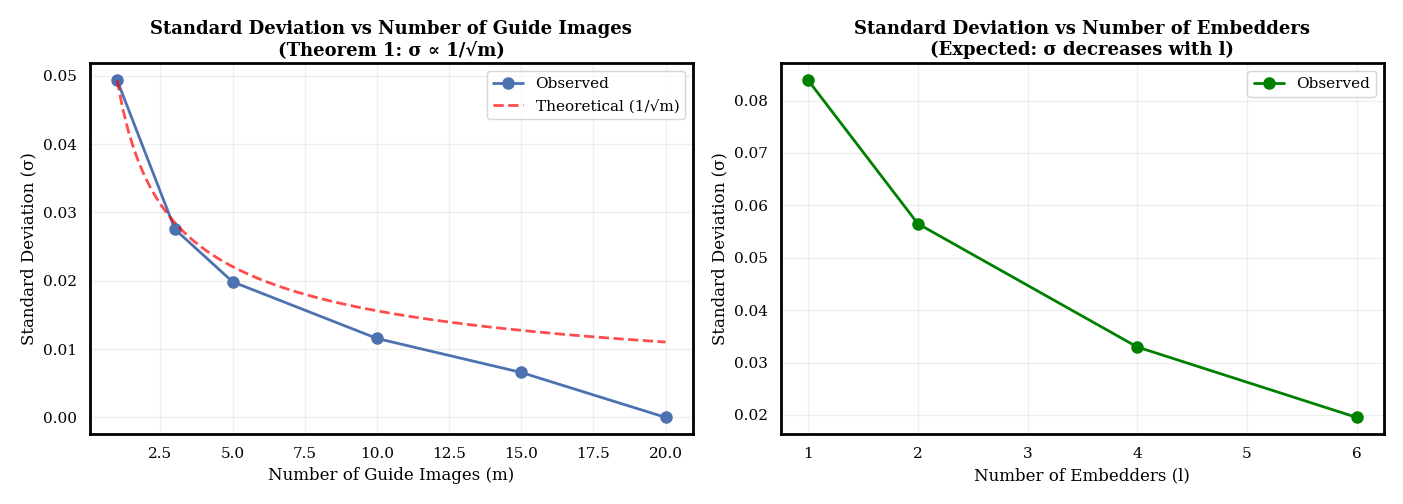


Plot saved as 'variance_reduction_analysis.png'


In [14]:
# Set style
sns.set_theme(style="whitegrid")

fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)

# plt.rcParams.update({
#     "font.size": 36,  # Increased base font size
#     "axes.titlesize": 36,  # Larger title
#     "axes.labelsize": 36,  # Larger axis labels
#     "legend.fontsize": 36,  # Larger legend
#     "xtick.labelsize": 32,  # Larger x-tick labels
#     "ytick.labelsize": 32,  # Larger y-tick labels
#     "figure.titlesize": 40,  # Larger figure title
# })

# Use professional serif font
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'normal'  # Changed from 'bold' to 'normal'

# High DPI for crisp text and lines
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.2

# Professional line and marker settings
plt.rcParams['lines.linewidth'] = 3.5
plt.rcParams['lines.markersize'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['figure.figsize'] = (14, 5)

# Plot 1: Standard Deviation vs Number of Guide Images (m)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Varying m
m_sorted = sorted(aggregated_m.keys())
stds_m = [aggregated_m[m][1] for m in m_sorted]

ax1.plot(m_sorted, stds_m, 'o-', linewidth=2, markersize=8, label='Observed')
ax1.set_xlabel('Number of Guide Images (m)', fontsize=12)
ax1.set_ylabel('Standard Deviation (σ)', fontsize=12)
ax1.set_title('Standard Deviation vs Number of Guide Images\n(Theorem 1: σ ∝ 1/√m)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add theoretical curve (1/√m) for comparison
m_theory = np.linspace(min(m_sorted), max(m_sorted), 100)
std_theory = stds_m[0] * np.sqrt(m_sorted[0]) / np.sqrt(m_theory)  # Normalize to match first point
ax1.plot(m_theory, std_theory, '--', linewidth=2, alpha=0.7, label='Theoretical (1/√m)', color='red')
ax1.legend()

# Varying l
l_sorted = sorted(aggregated_l.keys())
stds_l = [aggregated_l[l][1] for l in l_sorted]

ax2.plot(l_sorted, stds_l, 'o-', linewidth=2, markersize=8, color='green', label='Observed')
ax2.set_xlabel('Number of Embedders (l)', fontsize=12)
ax2.set_ylabel('Standard Deviation (σ)', fontsize=12)
ax2.set_title('Standard Deviation vs Number of Embedders\n(Expected: σ decreases with l)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('variance_reduction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'variance_reduction_analysis.png'")


## Step 7: Statistical Summary


In [15]:
# Create a summary table
import pandas as pd

summary_data = []
for m in sorted(aggregated_m.keys()):
    mean_dist, std_dist = aggregated_m[m]
    summary_data.append({
        'm': m,
        'Mean Distance': f"{mean_dist:.4f}",
        'Std Deviation (σ)': f"{std_dist:.4f}",
        'Relative Reduction': f"{(1 - std_dist / aggregated_m[M_VALUES[0]][1]) * 100:.1f}%"
    })

df_summary = pd.DataFrame(summary_data)
print("\nSummary Table (Varying m):")
print(df_summary.to_string(index=False))

# Save results to JSON
results_to_save = {
    'vary_m': {str(k): {'mean': v[0], 'std': v[1]} for k, v in aggregated_m.items()},
    'vary_l': {str(k): {'mean': v[0], 'std': v[1]} for k, v in aggregated_l.items()},
    'config': {
        'pool_size': POOL_SIZE,
        'bootstrap_iterations': BOOTSTRAP_ITERATIONS,
        'm_values': M_VALUES,
        'l_values': L_VALUES,
        'num_queries': len(all_results_vary_m) if all_results_vary_m else len(pools)
    }
}

with open('variance_analysis_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("\nResults saved to 'variance_analysis_results.json'")



Summary Table (Varying m):
 m Mean Distance Std Deviation (σ) Relative Reduction
 1        0.3755            0.0493               0.0%
 3        0.3770            0.0275              44.2%
 5        0.3766            0.0198              59.8%
10        0.3765            0.0116              76.6%
15        0.3768            0.0066              86.7%
20        0.3767            0.0000             100.0%

Results saved to 'variance_analysis_results.json'
